core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Usi

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Usi

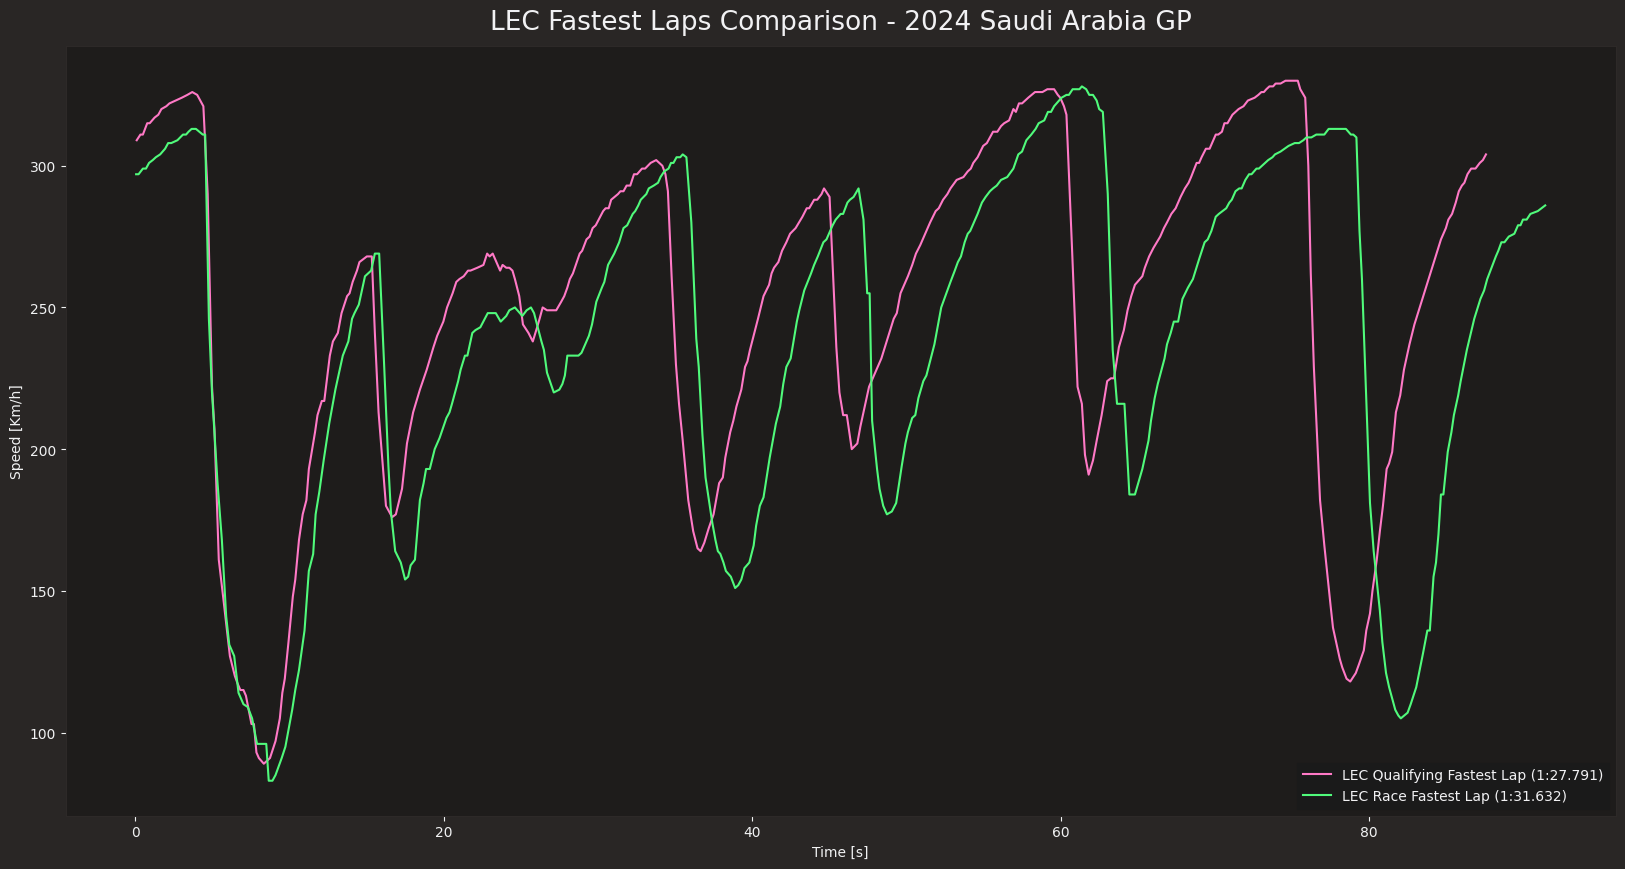

In [1]:
import fastf1
from fastf1 import get_session, plotting
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Setup Fast F1 with your specified cache path
cache_path = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\F1 Trial"
fastf1.Cache.enable_cache(cache_path)
plotting.setup_mpl()

def format_timedelta(seconds):
    # Given total seconds, returns formatted string mm:ss.sss
    minutes = int(seconds // 60)
    seconds = seconds % 60
    return f"{minutes}:{seconds:06.3f}"

def plot_fastest_laps(year, grand_prix, session_quali, session_race, drivers, use_plotly=True):
    quali_session = get_session(year, grand_prix, session_quali)
    quali_session.load()
    
    race_session = get_session(year, grand_prix, session_race)
    race_session.load()
    
    if use_plotly:
        fig = go.Figure()
    else:
        plt.figure(figsize=(20, 10))

    for driver in drivers:
        # Fetch and check data for both sessions
        for session, session_name in zip([quali_session, race_session], ['Qualifying', 'Race']):
            fastest_lap = session.laps.pick_driver(driver).pick_fastest()
            
            if fastest_lap is not None and not fastest_lap.empty:
                car_data = fastest_lap.get_car_data()
                times = [t.total_seconds() for t in car_data['Time']]
                speeds = car_data['Speed']
                lap_time = format_timedelta(fastest_lap['LapTime'].total_seconds())

                if use_plotly:
                    fig.add_trace(go.Scatter(x=times, y=speeds, mode='lines', name=f'{driver} {session_name} Fastest Lap ({lap_time})'))
                else:
                    plt.plot(times, speeds, label=f'{driver} {session_name} Fastest Lap ({lap_time})')
    
    if use_plotly:
        # Define tick values for the x-axis (every 10 seconds)
        max_time = max([t for session_data in [quali_session, race_session] for t in session_data.laps.pick_driver(driver).get_car_data()['Time']])
        max_t = max_time.total_seconds()
        tickvals = [i for i in range(0, int(max_t) + 10, 10)]
        ticktext = [format_timedelta(i) for i in tickvals]
        
        fig.update_layout(
            title=f'{", ".join(drivers)} Fastest Laps Comparison - {year} {grand_prix} GP',
            xaxis=dict(title='Time [s]', tickmode='array', tickvals=tickvals, ticktext=ticktext),
            yaxis=dict(title='Speed [Km/h]'),
            template='plotly_dark'
        )
        fig.show()
    else:
        # Matplotlib plotting
        plt.xlabel('Time [s]')
        plt.ylabel('Speed [Km/h]')
        plt.title(f'{", ".join(drivers)} Fastest Laps Comparison - {year} {grand_prix} GP')
        plt.legend()
        plt.show()

# Example usage for Plotly
plot_fastest_laps(2024, 'Saudi Arabia', 'Q', 'R', ['LEC'], use_plotly=True)

# Example usage for Matplotlib
plot_fastest_laps(2024, 'Saudi Arabia', 'Q', 'R', ['LEC'], use_plotly=False)


In [2]:
import fastf1
from fastf1 import get_session, plotting
import plotly.graph_objects as go

# Setup Fast F1 with your specified cache path
cache_path = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\F1 Trial"
fastf1.Cache.enable_cache(cache_path)
plotting.setup_mpl()

def format_timedelta(seconds):
    # Given total seconds, returns formatted string mm:ss.sss
    minutes = int(seconds // 60)
    seconds = seconds % 60
    return f"{minutes}:{seconds:06.3f}"

def plot_fastest_laps(year, grand_prix, session_quali, session_race, drivers):
    quali_session = get_session(year, grand_prix, session_quali)
    quali_session.load()
    
    race_session = get_session(year, grand_prix, session_race)
    race_session.load()
    
    fig = go.Figure()

    for driver in drivers:
        # Fetch and check qualifying data
        quali_fastest = quali_session.laps.pick_driver(driver).pick_fastest()
        if quali_fastest is not None and not quali_fastest.empty:
            quali_car_data = quali_fastest.get_car_data()
            quali_t = [t.total_seconds() for t in quali_car_data['Time']]
            quali_vCar = quali_car_data['Speed']
            quali_lap_time = format_timedelta(quali_fastest['LapTime'].total_seconds())
            fig.add_trace(go.Scatter(x=quali_t, y=quali_vCar, mode='lines', name=f'{driver} Quali Fastest Lap ({quali_lap_time})'))
        
        # Fetch and check race data
        race_fastest = race_session.laps.pick_driver(driver).pick_fastest()
        if race_fastest is not None and not race_fastest.empty:
            race_car_data = race_fastest.get_car_data()
            race_t = [t.total_seconds() for t in race_car_data['Time']]
            race_vCar = race_car_data['Speed']
            race_lap_time = format_timedelta(race_fastest['LapTime'].total_seconds())
            fig.add_trace(go.Scatter(x=race_t, y=race_vCar, mode='lines', name=f'{driver} Race Fastest Lap ({race_lap_time})'))

    # Define tick values for the x-axis (every 10 seconds)
    max_t = max(quali_t + race_t)
    tickvals = [i for i in range(0, int(max_t) + 10, 10)]
    ticktext = [format_timedelta(t) for t in tickvals]

    # Set plot layout with tick customization
    fig.update_layout(
        title=f'{", ".join(drivers)} Fastest Laps Comparison - {year} {grand_prix} GP',
        xaxis=dict(title='Time [s]', tickmode='array', tickvals=tickvals, ticktext=ticktext),
        yaxis=dict(title='Speed [Km/h]'),
        template='plotly_dark',
        plot_bgcolor='rgba(0, 0, 0, 0)',
        paper_bgcolor='rgba(0, 0, 0, 0)'
    )

    # Display the interactive plot
    fig.show()

# Example usage
plot_fastest_laps(2024, 'Saudi Arabia','Q','R', ['LEC', 'VER'])


core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap

In [3]:
plot_fastest_laps(2024, 'Saudi Arabia','Q','R', ['LEC', 'BEA'])


core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Usi

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']


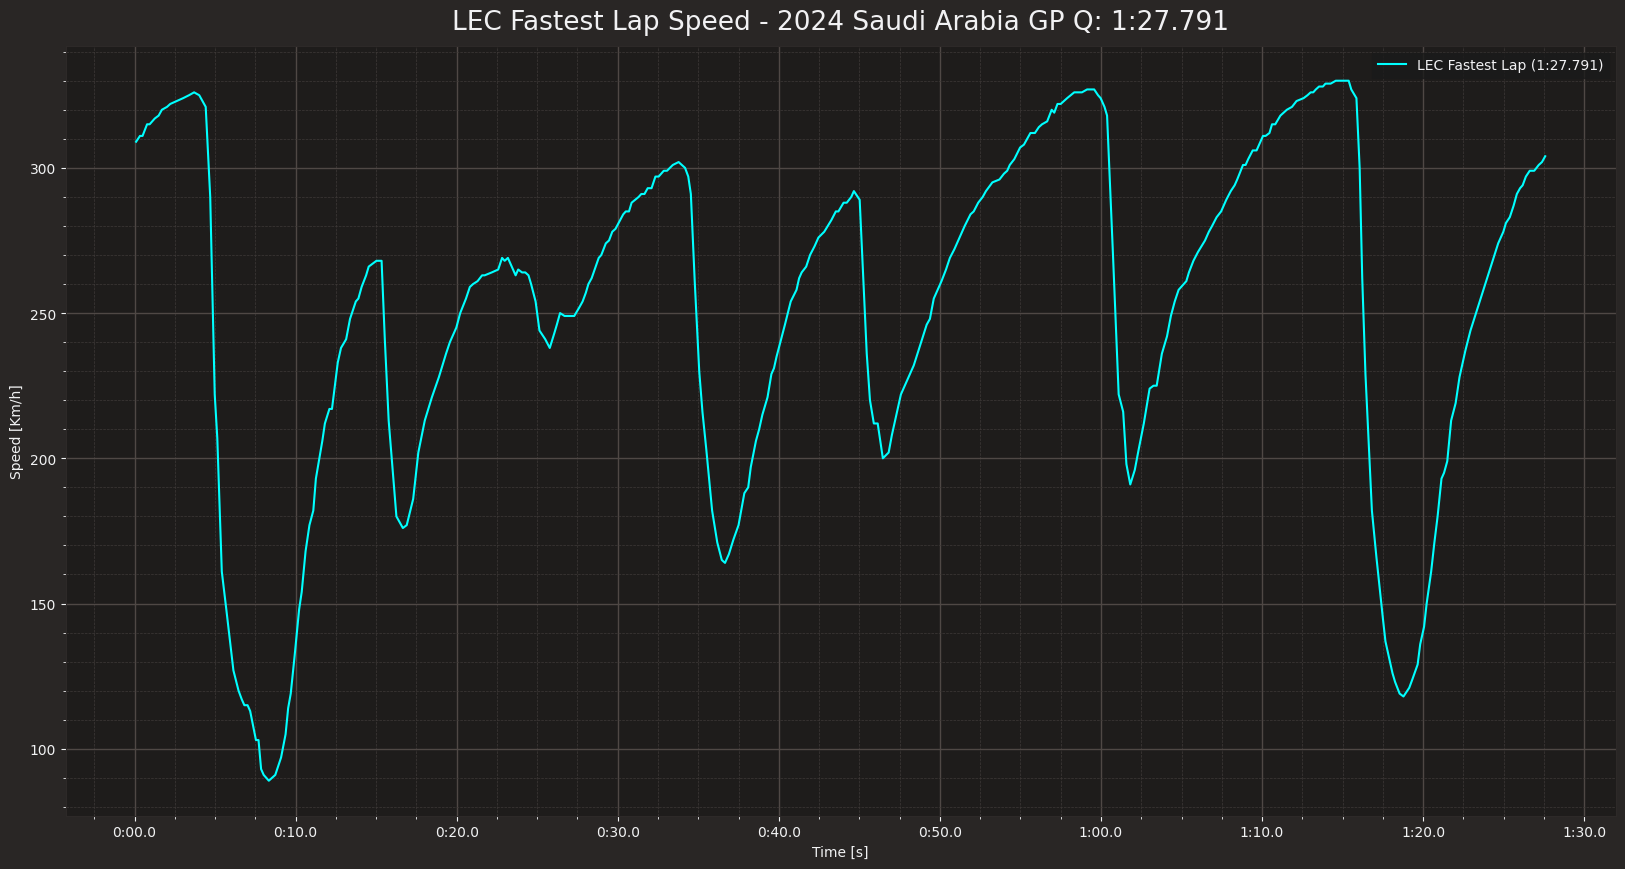

In [4]:
import matplotlib.pyplot as plt
import fastf1
import fastf1.plotting
from fastf1.core import Laps

def plot_driver_fastest_lap(year, gp_location, session_type, driver_code):
    # Setup the matplotlib for Fast F1
    fastf1.plotting.setup_mpl()

    # Load the session data
    session = fastf1.get_session(year, gp_location, session_type)
    session.load()

    # Fetch the fastest lap data for the specified driver
    fast_lap: Laps = session.laps.pick_driver(driver_code).pick_fastest()
    car_data = fast_lap.get_car_data()

    # Get time and speed data for plotting
    t = car_data['Time']
    vCar = car_data['Speed']

    # Get the driver's fastest lap time and format it
    lap_time_str = fast_lap['LapTime'].to_pytimedelta().total_seconds()
    formatted_lap_time = f"{lap_time_str // 60:.0f}:{lap_time_str % 60:06.3f}"

    # Plotting the data with an adjusted figure size
    figsize = (20, 10)  # Define the figure size
    fig, ax = plt.subplots(figsize=figsize)  # Apply the figure size
    ax.plot(t, vCar, label=f'{driver_code} Fastest Lap ({formatted_lap_time})', color='aqua')  # Plot data

    # Set labels and title
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Speed [Km/h]')
    ax.set_title(f'{driver_code} Fastest Lap Speed - {year} {gp_location} GP {session_type}: {formatted_lap_time}')

    # Add a legend
    ax.legend()

    # Display the plot
    plt.show()

# Example usage
plot_driver_fastest_lap(2024, 'Saudi Arabia', 'Q', 'LEC')


core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Usi

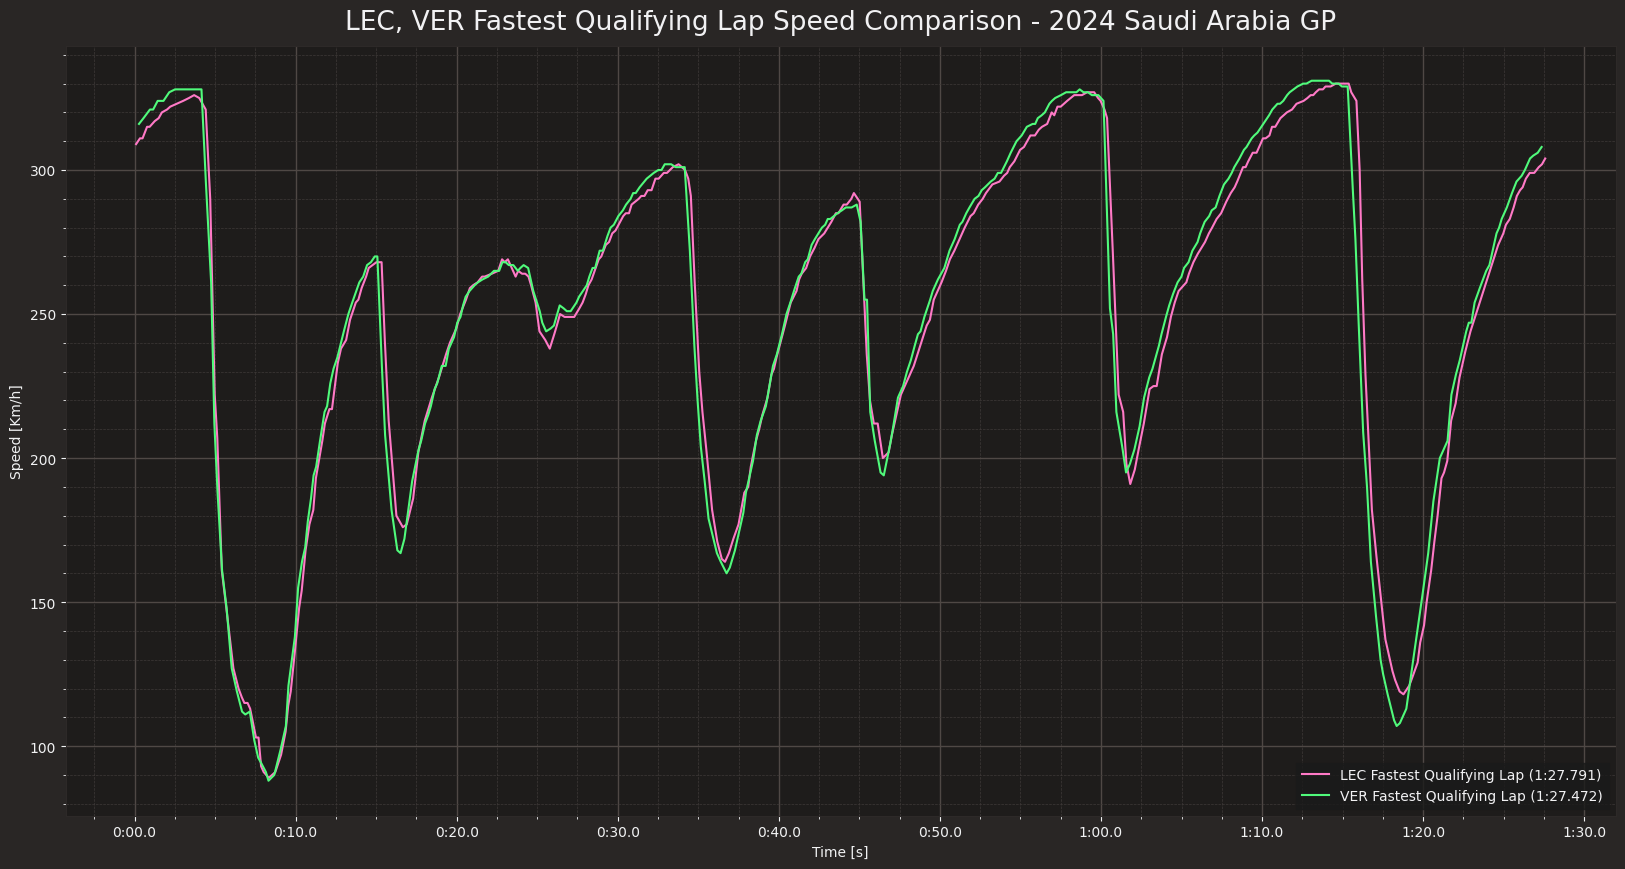

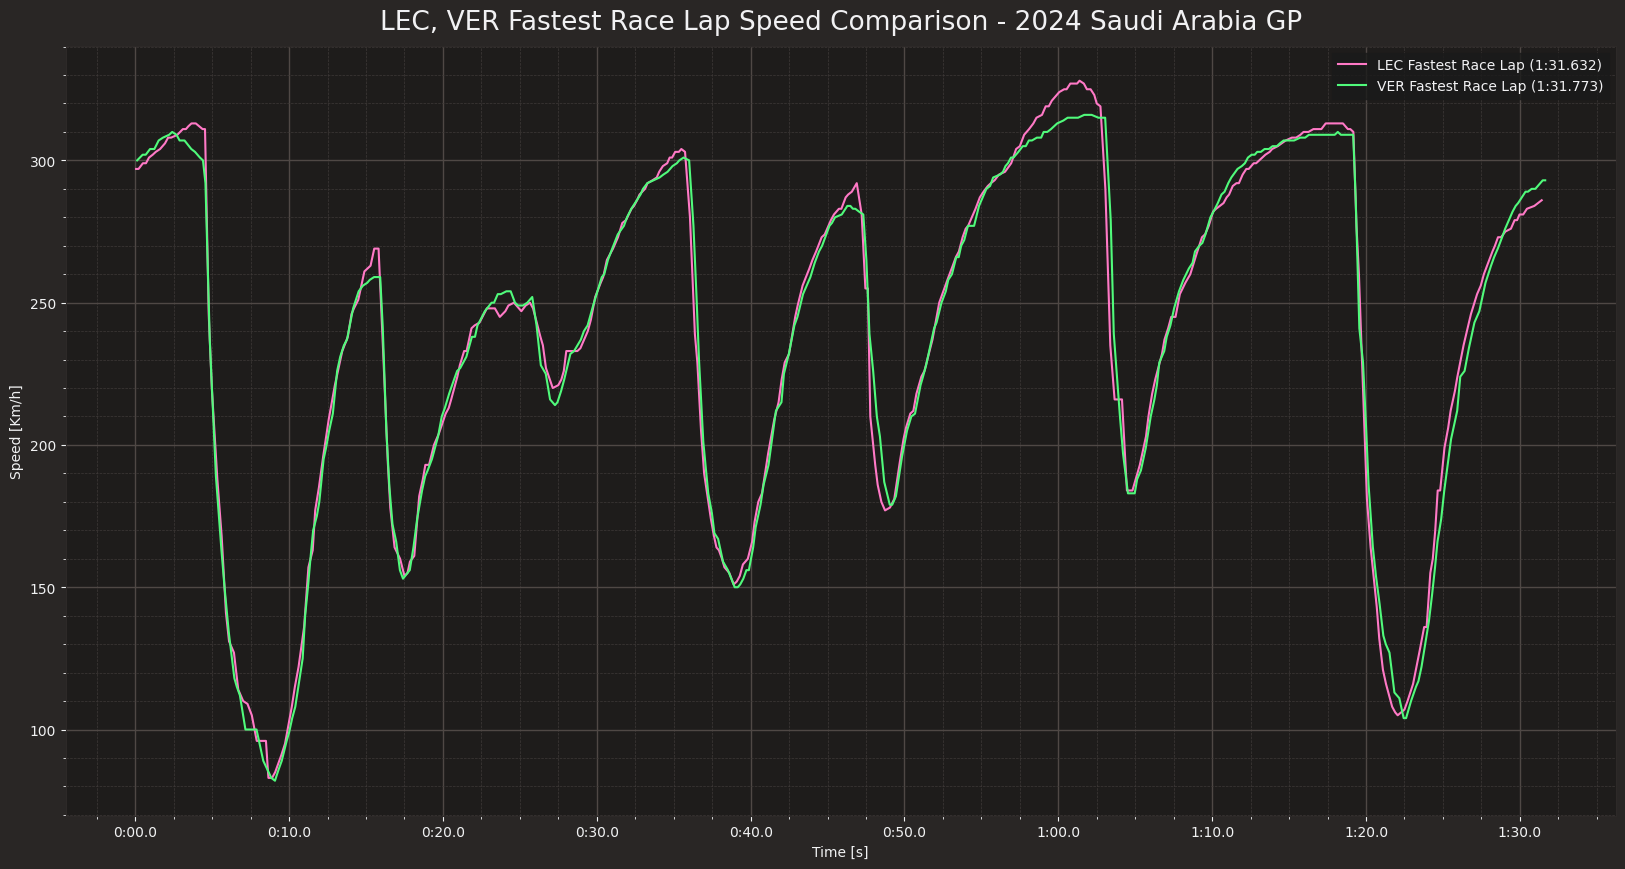

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Usi

In [5]:
import matplotlib.pyplot as plt
import fastf1
from fastf1 import get_session, plotting
import plotly.graph_objects as go

# Setup Fast F1 with your specified cache path
cache_path = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\F1 Trial"
fastf1.Cache.enable_cache(cache_path)
plotting.setup_mpl()

def format_timedelta(seconds):
    # Given total seconds, returns formatted string mm:ss.sss
    minutes = int(seconds // 60)
    seconds = seconds % 60
    return f"{minutes}:{seconds:06.3f}"

def plot_fastest_laps(year, grand_prix, session_quali, session_race, drivers, use_plotly=True):
    # Mapping session type codes to full names
    session_names = {'Q': 'Qualifying', 'R': 'Race'}

    # Fetch Formula 1 sessions
    quali_session = get_session(year, grand_prix, session_quali)
    quali_session.load()
    race_session = get_session(year, grand_prix, session_race)
    race_session.load()

    
    # Plotting logic for Plotly; Qualifying  and Race sessions
    if use_plotly:

        # Plotting logic for Plotly for Qualifying
        fig_quali = go.Figure()
        max_quali_time = 0
        for driver in drivers:
            fastest_lap = quali_session.laps.pick_driver(driver).pick_fastest()
            if fastest_lap is not None and not fastest_lap.empty:
                car_data = fastest_lap.get_car_data()
                times = [t.total_seconds() for t in car_data['Time']]
                max_quali_time = max(max_quali_time, max(times))
                speeds = car_data['Speed']
                lap_time = format_timedelta(fastest_lap['LapTime'].total_seconds())
                fig_quali.add_trace(go.Scatter(x=times, y=speeds, mode='lines', name=f'{driver} Qualifying Fastest Lap ({lap_time})'))

        # Define tick values for the x-axis for Qualifying
        tickvals_quali = [i for i in range(0, int(max_quali_time) + 10, 10)]
        ticktext_quali = [format_timedelta(i) for i in tickvals_quali]
        
        fig_quali.update_layout(
            title=f'{", ".join(drivers)} Fastest Qualifying Laps - {year} {grand_prix} GP',
            xaxis=dict(title='Time [s]', tickmode='array', tickvals=tickvals_quali, ticktext=ticktext_quali),
            yaxis=dict(title='Speed [Km/h]'),
            template='plotly_dark'
        )
        fig_quali.show()

        # Plotting logic for Plotly for Race
        fig_race = go.Figure()
        max_race_time = 0
        for driver in drivers:
            fastest_lap = race_session.laps.pick_driver(driver).pick_fastest()
            if fastest_lap is not None and not fastest_lap.empty:
                car_data = fastest_lap.get_car_data()
                times = [t.total_seconds() for t in car_data['Time']]
                max_race_time = max(max_race_time, max(times))
                speeds = car_data['Speed']
                lap_time = format_timedelta(fastest_lap['LapTime'].total_seconds())
                fig_race.add_trace(go.Scatter(x=times, y=speeds, mode='lines', name=f'{driver} Race Fastest Lap ({lap_time})'))

        # Define tick values for the x-axis for Race
        tickvals_race = [i for i in range(0, int(max_race_time) + 10, 10)]
        ticktext_race = [format_timedelta(i) for i in tickvals_race]

        fig_race.update_layout(
            title=f'{", ".join(drivers)} Fastest Race Laps - {year} {grand_prix} GP',
            xaxis=dict(title='Time [s]', tickmode='array', tickvals=tickvals_race, ticktext=ticktext_race),
            yaxis=dict(title='Speed [Km/h]'),
            template='plotly_dark'
        )
        fig_race.show()
    else:
        # Plotting logic for Matplotlib
        def plot_with_matplotlib(session, session_name, driver_codes):
            figsize = (20, 10)
            fig, ax = plt.subplots(figsize=figsize)
            for driver_code in driver_codes:
                fast_lap = session.laps.pick_driver(driver_code).pick_fastest()
                if fast_lap is not None and not fast_lap.empty:
                    car_data = fast_lap.get_car_data()
                    t = car_data['Time']
                    vCar = car_data['Speed']
                    lap_time_str = format_timedelta(fast_lap['LapTime'].total_seconds())
                    ax.plot(t, vCar, label=f'{driver_code} Fastest {session_name} Lap ({lap_time_str})')
            ax.set_xlabel('Time [s]')
            ax.set_ylabel('Speed [Km/h]')
            ax.set_title(f'{", ".join(driver_codes)} Fastest {session_name} Lap Speed Comparison - {year} {grand_prix} GP')
            ax.legend()
            plt.show()

        # Invoke Matplotlib plotting
        
        # Plot Qualifying session if requested
        if 'Q' in [session_quali, session_race]:
            plot_with_matplotlib(quali_session, session_names['Q'], drivers)

        # Plot Racing session if requested
        if 'R' in [session_quali, session_race]:
            plot_with_matplotlib(race_session, session_names['R'], drivers)

# Fastest Laps using matplotib.
plot_fastest_laps(2024, 'Saudi Arabia', 'Q', 'R', ['LEC', 'VER'], use_plotly=False)
# Using Plotly
plot_fastest_laps(2024, 'Saudi Arabia', 'Q', 'R', ['LEC', 'VER'], use_plotly=True)

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Usi

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Usi

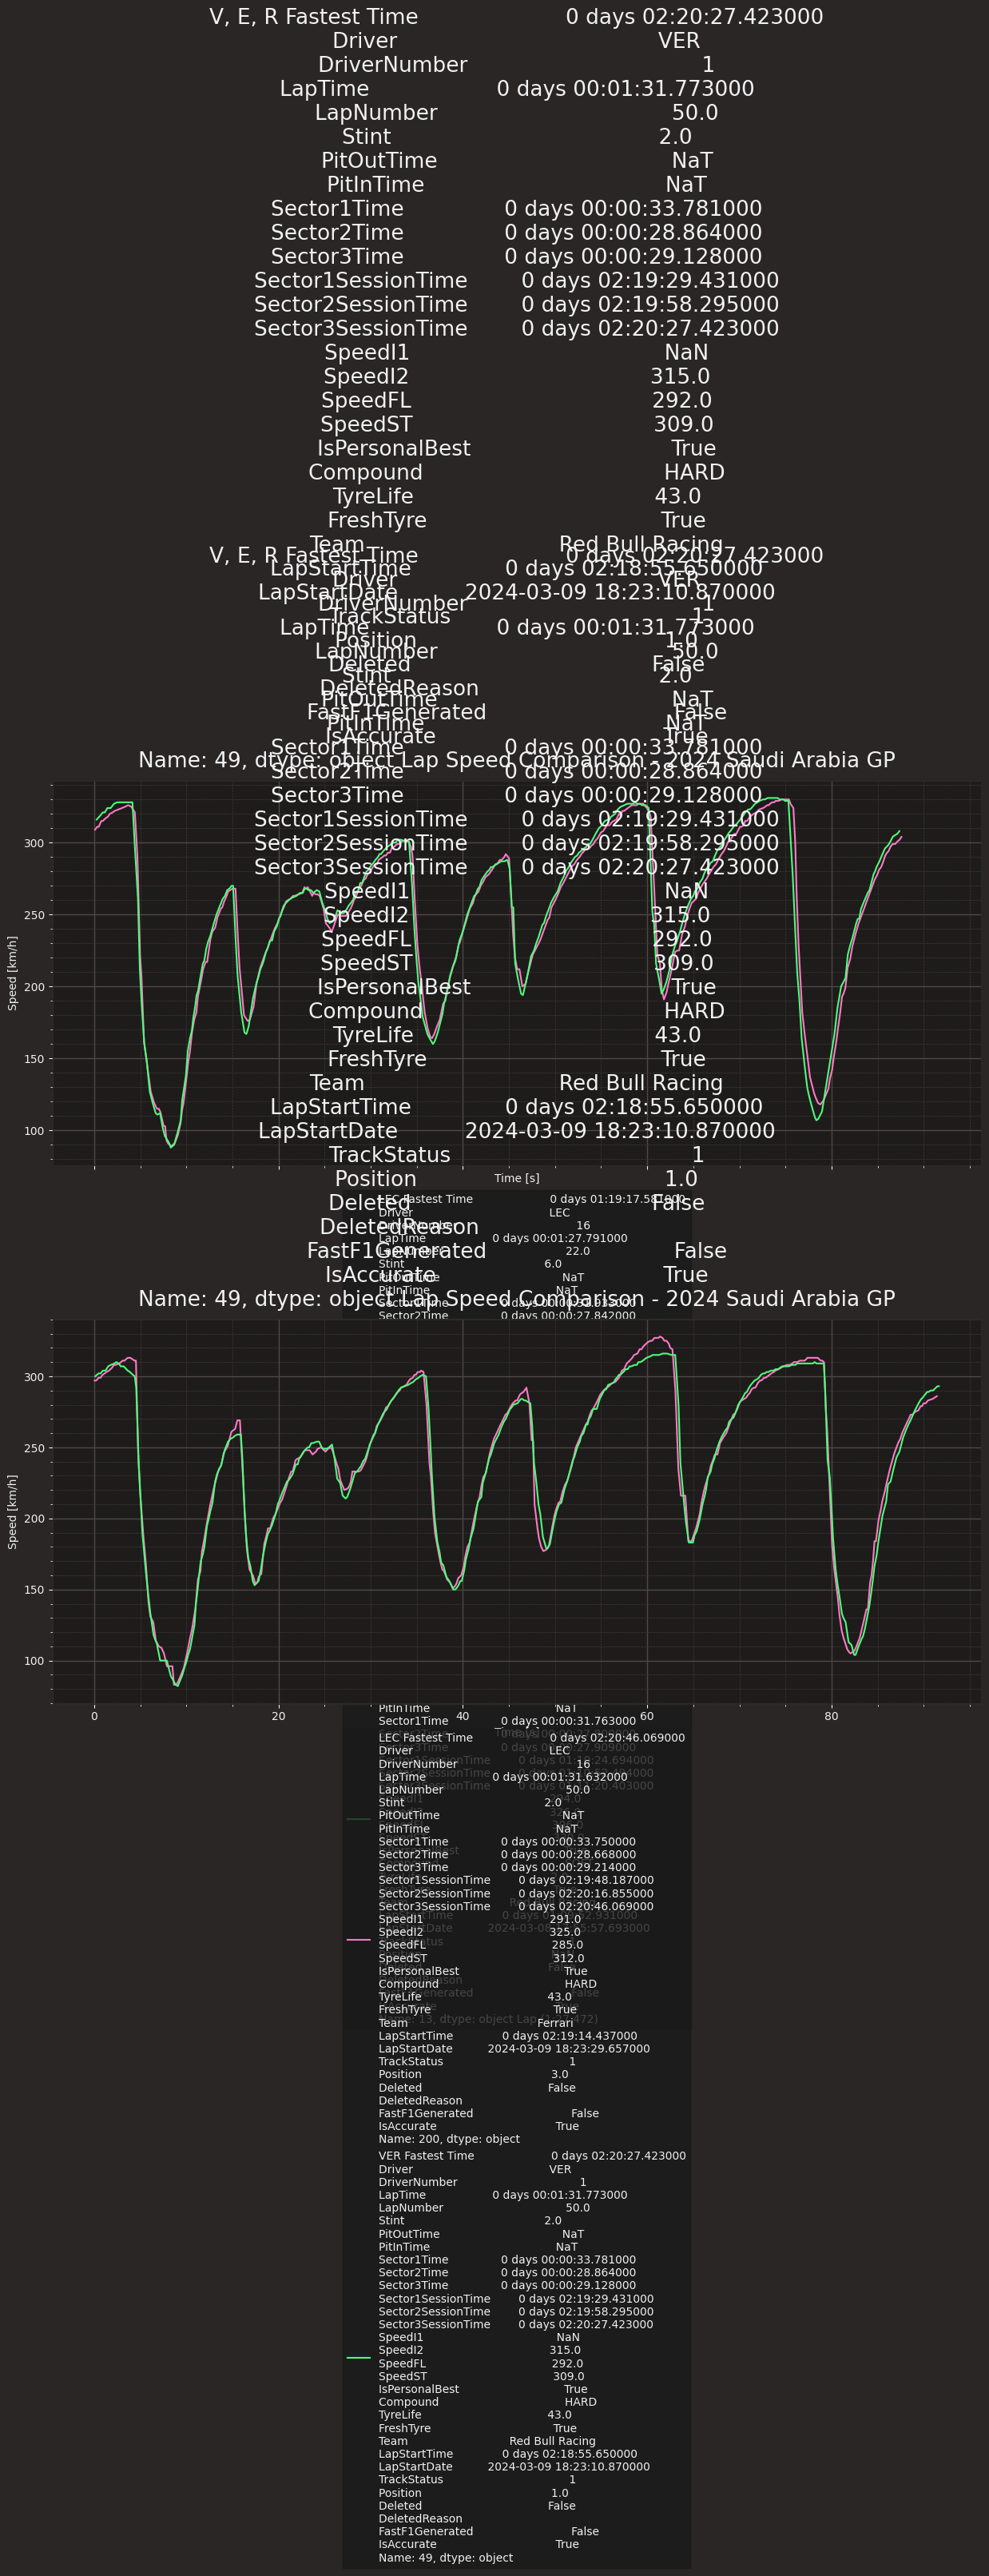

In [6]:



import matplotlib.pyplot as plt
import fastf1
from fastf1 import get_session, plotting
import numpy as np
import plotly.graph_objects as go

# Setup Fast F1 with your specified cache path
cache_path = "C:\\Users\\moses_y\\OneDrive\\Desktop\\ML Projects\\F1 Trial"
fastf1.Cache.enable_cache(cache_path)
plotting.setup_mpl()

def format_timedelta(seconds):
    # Given total seconds, returns formatted string mm:ss.sss
    minutes = int(seconds // 60)
    seconds = seconds % 60
    return f"{minutes}:{seconds:06.3f}"

def create_matplotlib_figures(year, grand_prix, quali_session, race_session, drivers):
    # Initialize max time variables
    max_quali_time, max_race_time = 0, 0

    # Determine max time in Qualifying and Race sessions to set x-axis limits uniformly
    for driver in drivers:
        fastest_quali_lap = quali_session.laps.pick_driver(driver).pick_fastest()
        if fastest_quali_lap is not None and not fastest_quali_lap.empty:
            quali_car_data = fastest_quali_lap.get_car_data()
            max_quali_time = max(max_quali_time, max(quali_car_data['Time'].dt.total_seconds()))

        fastest_race_lap = race_session.laps.pick_driver(driver).pick_fastest()
        if fastest_race_lap is not None and not fastest_race_lap.empty:
            race_car_data = fastest_race_lap.get_car_data()
            max_race_time = max(max_race_time, max(race_car_data['Time'].dt.total_seconds()))

    # Define consistent x-axis tick values and labels based on the longer of the two max times
    max_time = max(max_quali_time, max_race_time)
    tick_vals = np.arange(0, int(max_time) + 10, 10)
    tick_labels = [format_timedelta(val) for val in tick_vals]

    # Plotting logic for Matplotlib; Qualifying and Race sessions
    #fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 15), sharex=True)
    # Plot Qualifying
    for driver in drivers:
        fastest_quali_lap = quali_session.laps.pick_driver(driver).pick_fastest()
        if fastest_quali_lap is not None and not fastest_quali_lap.empty:
            quali_car_data = fastest_quali_lap.get_car_data()
            times = quali_car_data['Time'].dt.total_seconds()
            speeds = quali_car_data['Speed']
            lap_time_str = format_timedelta(fastest_quali_lap['LapTime'].total_seconds())
            ax1.plot(times, speeds, label=f'{driver} Fastest {fastest_quali_lap} Lap ({lap_time_str})')

    ax1.set_title(f'{", ".join(driver)} Fastest {fastest_race_lap} Lap Speed Comparison - {year} {grand_prix} GP')
    ax1.set_xlabel('Time [s]')
    #ax1.set_xticks(tick_vals)
    #ax1.set_xticklabels(tick_labels, rotation=45)
    ax1.set_ylabel('Speed [km/h]')
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05))

    # Plot Race
    for driver in drivers:
        fastest_race_lap = race_session.laps.pick_driver(driver).pick_fastest()
        if fastest_race_lap is not None and not fastest_race_lap.empty:
            race_car_data = fastest_race_lap.get_car_data()
            times = race_car_data['Time'].dt.total_seconds()
            speeds = race_car_data['Speed']
            lap_time_str = format_timedelta(fastest_race_lap['LapTime'].total_seconds())
            ax2.plot(times, speeds, label=f'{driver} Fastest {fastest_race_lap} ')
                
    ax2.set_title(f'{", ".join(driver)} Fastest {fastest_race_lap} Lap Speed Comparison - {year} {grand_prix} GP')
    ax2.set_xlabel('Time [s]')
    #ax2.set_xticks(tick_vals)
    #ax2.set_xticklabels(tick_labels, rotation=45)
    ax2.set_ylabel('Speed [km/h]')
    ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05))

    #plt.tight_layout()
    fig.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.show()

def create_plotly_figures(year, grand_prix, session, session_name, drivers):
    fig = go.Figure()
    max_time = 0

    for driver in drivers:
        fastest_lap = session.laps.pick_driver(driver).pick_fastest()
        if fastest_lap is not None and not fastest_lap.empty:
            car_data = fastest_lap.get_car_data()
            times = [t.total_seconds() for t in car_data['Time']]
            max_time = max(max_time, max(times))
            speeds = car_data['Speed']
            lap_time = format_timedelta(fastest_lap['LapTime'].total_seconds())
            fig.add_trace(go.Scatter(x=times, y=speeds, mode='lines', name=f'{driver} {session_name} Fastest Lap ({lap_time})'))
    
    tickvals = [i for i in range(0, int(max_time) + 10, 10)]
    ticktext = [format_timedelta(i) for i in tickvals]

    fig.update_layout(
        title=f'{", ".join(drivers)} Fastest {session_name} Laps - {year} {grand_prix} GP',
        xaxis=dict(title='Time [s]', tickmode='array', tickvals=tickvals, ticktext=ticktext),
        yaxis=dict(title='Speed [Km/h]'),
        template='plotly_dark'
    )

    fig.show()

def plot_fastest_laps(year, grand_prix, session_quali, session_race, drivers, use_plotly=True):
    quali_session = get_session(year, grand_prix, session_quali)
    quali_session.load()
    race_session = get_session(year, grand_prix, session_race)
    race_session.load()

    if use_plotly:
        create_plotly_figures(year, grand_prix, quali_session, "Qualifying", drivers)
        create_plotly_figures(year, grand_prix, race_session, "Race", drivers)
    else:
        create_matplotlib_figures(year, grand_prix, quali_session, race_session, drivers)
        plt.show()

# Example usage for Plotly
plot_fastest_laps(2024, 'Saudi Arabia', 'Q', 'R', ['LEC', 'VER'], use_plotly=True)

# Example usage for Matplotlib
plot_fastest_laps(2024, 'Saudi Arabia', 'Q', 'R', ['LEC', 'VER'], use_plotly=False)


In [2]:
import os
import pandas as pd
import fastf1
from fastf1 import get_session, plotting
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import requests
from datetime import datetime

# Setup cache directory for FastF1
CACHE_PATH = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\F1 Trial\fastf1_cache"
if not os.path.exists(CACHE_PATH):
    os.makedirs(CACHE_PATH)
fastf1.Cache.enable_cache(CACHE_PATH)
plotting.setup_mpl()

# Function to fetch data from Ergast API
def fetch_ergast_data(endpoint):
    url = f"https://ergast.com/api/f1/{endpoint}.json"
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()
    except requests.RequestException as e:
        print(f"Failed to fetch data: {e}")
        return None

# Fetch F1 schedule for the current year
def fetch_schedule(year):
    return fetch_ergast_data(f"{year}")

# Load and cache data using FastF1
def fetch_and_cache_session_data(year, grand_prix, session_type):
    session = get_session(year, grand_prix, session_type)
    session.load()
    return session

# Format timedelta to a readable string
def format_timedelta(seconds):
    minutes = int(seconds // 60)
    seconds = seconds % 60
    milliseconds = int((seconds % 1) * 1000)
    return f"{minutes}:{int(seconds):02d}:{milliseconds:03d}"

# Fetch weather data
def fetch_weather_data(session):
    weather_data = session.weather_data
    if weather_data is not None:
        weather_info = weather_data.iloc[0]  # Get the first weather sample
        return f"Weather: {weather_info['AirTemp']}°C, {weather_info['Humidity']}% Humidity, Wind {weather_info['WindSpeed']} m/s"
    return "Weather data not available"

# Plot fastest laps using Plotly and Matplotlib
def plot_fastest_laps(year, grand_prix, session_quali, session_race, drivers, use_plotly=True):
    quali_session = fetch_and_cache_session_data(year, grand_prix, session_quali)
    race_session = fetch_and_cache_session_data(year, grand_prix, session_race)
    
    if use_plotly:
        fig = go.Figure()
    else:
        plt.figure(figsize=(20, 10))
    
    for driver in drivers:
        for session, session_name in zip([quali_session, race_session], ['Qualifying', 'Race']):
            fastest_lap = session.laps.pick_driver(driver).pick_fastest()
            if fastest_lap is not None and not fastest_lap.empty and 'DriverNumber' in fastest_lap:
                car_data = session.car_data.get(fastest_lap['DriverNumber'])
                if car_data is not None:
                    times = [t.total_seconds() for t in car_data['Time']]
                    speeds = car_data['Speed']
                    lap_time = format_timedelta(fastest_lap['LapTime'].total_seconds())
                    
                    if use_plotly:
                        fig.add_trace(go.Scatter(x=times, y=speeds, mode='lines', name=f'{driver} {session_name} Fastest Lap ({lap_time})'))
                    else:
                        plt.plot(times, speeds, label=f'{driver} {session_name} Fastest Lap ({lap_time})')
                else:
                    print(f"No car data found for driver {driver} in {session_name} session of {grand_prix}.")
            else:
                print(f"No valid fastest lap data for driver {driver} in {session_name} session of {grand_prix}.")
    
    if use_plotly:
        max_time = max([t.total_seconds() for session in [quali_session, race_session] for t in session.laps.pick_driver(drivers[0]).get_car_data()['Time']])
        tickvals = [i for i in range(0, int(max_time) + 10, 10)]
        ticktext = [format_timedelta(i) for i in tickvals]
        
        fig.update_layout(
            title=f'{", ".join(drivers)} Fastest Laps Comparison - {year} {grand_prix} GP',
            xaxis=dict(title='Time [s]', tickmode='array', tickvals=tickvals, ticktext=ticktext),
            yaxis=dict(title='Speed [Km/h]'),
            template='plotly_dark'
        )

        # Adding sector lines and annotations
        for session in [quali_session, race_session]:
            sectors = session.laps.pick_driver(drivers[0]).pick_fastest().get_sector_times()
            sector_times = [s.total_seconds() for s in sectors if s is not None]
            for sector_time in sector_times:
                fig.add_vline(x=sector_time, line=dict(color='White', dash='dash'))
                fig.add_annotation(x=sector_time, y=max(speeds), text=f"Sector {sector_times.index(sector_time) + 1}", showarrow=True, arrowhead=1)

        # Adding weather data annotation
        weather_info = fetch_weather_data(quali_session)
        fig.add_annotation(x=0.5, y=1.15, xref='paper', yref='paper', text=weather_info, showarrow=False, font=dict(size=12))

        fig.show()
    else:
        plt.xlabel('Time [s]')
        plt.ylabel('Speed [Km/h]')
        plt.title(f'{", ".join(drivers)} Fastest Laps Comparison - {year} {grand_prix} GP')
        plt.legend()
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)

        # Adding sector lines and annotations
        for session in [quali_session, race_session]:
            sectors = session.laps.pick_driver(drivers[0]).pick_fastest().get_sector_times()
            sector_times = [s.total_seconds() for s in sectors if s is not None]
            for sector_time in sector_times:
                plt.axvline(x=sector_time, color='gray', linestyle='--')
                plt.text(sector_time, max(speeds), f"Sector {sector_times.index(sector_time) + 1}", rotation=90, verticalalignment='bottom')

        # Adding weather data annotation
        weather_info = fetch_weather_data(quali_session)
        plt.annotate(weather_info, xy=(0.5, 1.05), xycoords='axes fraction', ha='center', fontsize=12)

        plt.show()

# Main function to fetch data and plot
def main():
    year = 2024
    schedule = fetch_schedule(year)
    
    if schedule:
        for race in schedule['MRData']['RaceTable']['Races']:
            grand_prix = race['raceName']
            round_number = race['round']
            race_date = datetime.strptime(race['date'], '%Y-%m-%d')
            
            if race_date <= datetime.now():
                print(f"Plotting data for: {grand_prix} on {race['date']}")
                try:
                    plot_fastest_laps(year, grand_prix, 'Q', 'R', ['LEC', 'SAI'], use_plotly=True)
                    plot_fastest_laps(year, grand_prix, 'Q', 'R', ['LEC', 'SAI'], use_plotly=False)
                except Exception as e:
                    print(f"Error plotting data for {grand_prix}: {e}")

if __name__ == "__main__":
    main()


Plotting data for: Bahrain Grand Prix on 2024-03-02


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.3.1]
req            INFO 	Using cached da

Error plotting data for Bahrain Grand Prix: 'Lap' object has no attribute 'get_sector_times'
Plotting data for: Saudi Arabian Grand Prix on 2024-03-09


req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_

No car data found for driver SAI in Qualifying session of Saudi Arabian Grand Prix.
No car data found for driver SAI in Race session of Saudi Arabian Grand Prix.
Error plotting data for Saudi Arabian Grand Prix: 'Lap' object has no attribute 'get_sector_times'
Plotting data for: Australian Grand Prix on 2024-03-24


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['1', '55', '11', '4', '16', '81', '63', '22', '18', '14', '44', '23', '77', '20', '31', '27', '10', '3', '24']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.3.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
